<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [1]:
import os
import re
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore")

# Стиль визуализации
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"

print("[ОК] Все библиотеки успешно импортированы")

C:\Users\Asus\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


[ОК] Все библиотеки успешно импортированы


In [2]:
pd.set_option("display.max_columns", 60)

BASE_PROJECT_DIR = r"C:\Users\Asus\OneDrive\Рабочий стол\Project ML ITMO\Модуль №3 ML System Design and MFDP\MFDP"

# Сборка абсолютного пути к итоговому промежуточному CSV-файлу после NLP-разметки
csv_path = os.path.join(BASE_PROJECT_DIR, "data", "interim", "data_interim_vacancies.csv")

if not os.path.exists(csv_path):
    print(f"Файл физически отсутствует по пути: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    print(f"Матрица признаков успешно загружена из CSV!")
    print(f"Итоговый размер очищенного датасета: {df.shape} (строк, колонок)")
    
    # Выводим типы данных и количество непустых значений
    print("\n Матрица произнаков")
    display(df)

Матрица признаков успешно загружена из CSV!
Итоговый размер очищенного датасета: (1853, 65) (строк, колонок)

 Матрица произнаков


,role_name_raw,role_class,experience_months,region_tier,bank_tier,is_foreign_currency,is_grade_junior,is_grade_middle,is_grade_senior,is_grade_management,edu_level_encoded,salary_from,salary_to,y_offer,is_vacancy,skill_general_negotiations,skill_vip_negotiations,skill_active_listening,skill_persuasion_argumentation,skill_public_presentation,skill_business_correspondence,skill_cold_sales,skill_telemarketing,skill_objection_handling,skill_cross_sales,skill_difficult_clients,skill_conflict_resolution,skill_stress_resistance,skill_adaptability_flexibility,skill_teamwork,...,skill_advanced_excel,skill_python_automation,skill_sql_queries,skill_bi_analytics,skill_business_eda,skill_predictive_modeling,skill_java_backend,skill_devops_cicd,skill_big_data_stack,skill_finance_cert_cfa,skill_finance_cert_frm,skill_finance_cert_fsfr,skill_kpi_system_management,skill_kpi_troubleshooting_eda,skill_sales_book_analysis,skill_result_defense_data,skill_roleplay_defense,skill_dynamic_field_adaptation,skill_rapid_learning_testing,skill_pnl_product_metrics,skill_banking_regulation_basel,skill_compliance_aml_kyc,skill_hr_analytics_metrics,has_car_and_driver_license,has_remote_hybrid_schedule,skill_english_proficiency,skills_completion_rate,text_pca_1,text_pca_2,text_pca_3
0,Представитель в Т-Банк,1,0,Tier-3,Bank_Tier_1,0,0,1,0,0,0,150000.0,NaN,172500.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,-1.347195,0.895956,-0.642938
1,Клиентский менеджер отделения банка,8,0,Tier-3,Bank_Tier_1,0,0,1,0,0,0,120000.0,NaN,138000.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.042553,-1.087946,-0.427134,-1.651151
2,Представитель в Т-Банке,1,0,Tier-3,Bank_Tier_1,0,0,1,0,0,0,140000.0,NaN,161000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,-1.187722,0.704184,-0.838953
3,Представитель в Т-Банк,1,0,Tier-3,Bank_Tier_1,0,0,1,0,0,0,140000.0,NaN,161000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,-1.187722,0.704183,-0.838953
4,Представитель Т-Банка,1,0,Tier-3,Bank_Tier_1,0,0,1,0,0,0,140000.0,NaN,161000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,-1.187722,0.704183,-0.838953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1848,Заместитель начальника сектора по подбору и ад...,31,24,Tier-3,Bank_Tier_3,0,0,0,0,1,0,100000.0,NaN,115000.0,1,1,0,0,1,0,0,0,0,0,1,0,1,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.276596,-0.968537,-0.750118,1.559375
1849,Куратор по автоматизации процессов подбора пер...,31,24,Tier-3,Bank_Tier_3,0,0,1,0,0,1,250000.0,NaN,287500.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.106383,1.595699,-2.603622,0.632898
1850,Специалист в отдел методологии и управления пр...,31,0,Tier-3,Bank_Tier_3,0,0,1,0,0,1,100000.0,NaN,115000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.063830,0.974213,-1.851462,0.758674
1851,HR менеджер,31,24,Tier-3,Bank_Tier_3,0,0,1,0,0,0,50000.0,70000.0,60000.0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.191489,-1.262444,-0.166611,-0.596756


In [3]:
print("Анализ источника и структуры датасета")

vacancies_count = df[df['is_vacancy'] == 1].shape[0]
total_rows = df.shape[0]

print(f"Источник данных: Развернутые HTML-страницы вакансий hh.ru")
print(f"Общий объем семантической матрицы X: {total_rows} строк.")
print(f"  > Вакансии финансовых организаций (B2B): {vacancies_count} строк ({vacancies_count/total_rows:.1%})")

print("Проверим статистическую достаточность проекта")
num_features = df.shape[1]
print(f"Количество извлеченных NLP-признаков матрицы X: {num_features}")

# соотношение объема строк к числу признаков
rows_to_features_ratio = total_rows / num_features
print(f"Фактическое соотношение строк к признакам: {rows_to_features_ratio:.1f}x")

if rows_to_features_ratio >= 20:
    print(f"Выборка в {total_rows} строк превышает количество фичей в {rows_to_features_ratio:.1f} раз.")
    print("Вывод: Сформированный датасет стабилен")
else:
    print("[ВНИМАНИЕ] Рекомендуется увеличить объем данных или сократить пространство признаков.")

Анализ источника и структуры датасета
Источник данных: Развернутые HTML-страницы вакансий hh.ru
Общий объем семантической матрицы X: 1853 строк.
  > Вакансии финансовых организаций (B2B): 1853 строк (100.0%)
Проверим статистическую достаточность проекта
Количество извлеченных NLP-признаков матрицы X: 65
Фактическое соотношение строк к признакам: 28.5x
Выборка в 1853 строк превышает количество фичей в 28.5 раз.
Вывод: Сформированный датасет стабилен


ФИЛЬТРАЦИЯ И СТАТИСТИКА МАТРИЦЫ X ===
Гибридный расчет порогов фильтрации:
  > Жесткая нижняя планка (Full-Time b2b порог): 27000 руб.
  > Динамическая верхняя планка (99-й процентиль): 850000 руб.

 Удалено мусорных строк: 19 шт.
Итоговый объем стерильного датасета: 1834 строк.

 Новое распределение по четырем макроэкономическим уровням:
Tier-1      61
Tier-2      31
Tier-3    1741
Tier-4       1
Name: region_tier, dtype: int64

Итоговая чистая статистика по макроэкономическим уровням (БЕЗ ВЫБРОСОВ):


,Кол-во вакансий,Среднее (руб),Медиана (руб),Минимум (руб),Максимум (руб)
region_tier,,,,,
Tier-1,61,182427.0,152500.0,50000.0,850000.0
Tier-2,31,119869.0,104150.0,48875.0,357000.0
Tier-3,1741,161798.0,141508.0,37500.0,690000.0
Tier-4,1,126500.0,126500.0,126500.0,126500.0


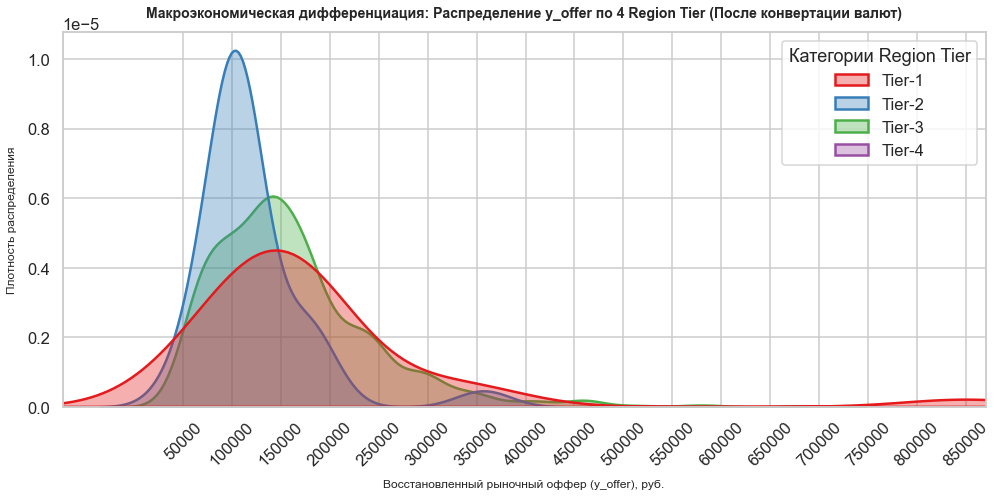

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("ФИЛЬТРАЦИЯ И СТАТИСТИКА МАТРИЦЫ X ===")

# Нижня планка выставляется по экономическому минимуму Full-Time вакансий банков
lower_bound = 27000 

# Верхняя планка рассчитывается динамически по 99-му процентилю (срез случайных опечаток)
upper_bound = df['y_offer'].quantile(0.99)

print(f"Гибридный расчет порогов фильтрации:")
print(f"  > Жесткая нижняя планка (Full-Time b2b порог): {lower_bound} руб.")
print(f"  > Динамическая верхняя планка (99-й процентиль): {upper_bound:.0f} руб.")

# Применяем фильтрацию к нашему новому датасету
df_clean = df[(df['y_offer'] >= lower_bound) & (df['y_offer'] <= upper_bound)].copy()

# Фиксируем четырехуровневую структуру географии рынка
tier_order = ['Tier-1', 'Tier-2', 'Tier-3', 'Tier-4']
df_clean['region_tier'] = pd.Categorical(df_clean['region_tier'], categories=tier_order, ordered=True)

print(f"\n Удалено мусорных строк: {len(df) - len(df_clean)} шт.")
print(f"Итоговый объем стерильного датасета: {len(df_clean)} строк.")
print("\n Новое распределение по четырем макроэкономическим уровням:")
print(df_clean['region_tier'].value_counts().sort_index())

# Переприсваиваем DataFrame для дальнейшей работы
df = df_clean.copy()

# Расчет чистой зарплатной b2b-статистики по 4 тирам
geo_salary_stats_clean = df.groupby('region_tier', observed=False)['y_offer'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(0)

# Приводим к презентабельному виду
geo_salary_stats_clean.columns = ['Кол-во вакансий', 'Среднее (руб)', 'Медиана (руб)', 'Минимум (руб)', 'Максимум (руб)']
print("\nИтоговая чистая статистика по макроэкономическим уровням (БЕЗ ВЫБРОСОВ):")
display(geo_salary_stats_clean)

# Построение графика плотности (Ядерная оценка плотности KDE)
plt.figure(figsize=(14, 7))

sns.kdeplot(
    data=df, 
    x='y_offer', 
    hue='region_tier', 
    fill=True, 
    common_norm=False, 
    palette='Set1',
    alpha=0.35,
    linewidth=2.5
)

# Оформление графика
plt.title('Макроэкономическая дифференциация: Распределение y_offer по 4 Region Tier (После конвертации валют)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Восстановленный рыночный оффер (y_offer), руб.', fontsize=12, labelpad=10)
plt.ylabel('Плотность распределения', fontsize=12, labelpad=10)

# Динамический масштаб графика
plt.xlim(lower_bound - 100000, upper_bound + 20000) 
plt.ticklabel_format(style='plain', axis='x')

# Сетка с шагом в 50 000 рублей
plt.xticks(range(50000, int(upper_bound) + 50000, 50000), rotation=45)

if plt.gca().get_legend() is not None:
    plt.gca().get_legend().set_title('Категории Region Tier')

plt.tight_layout()
plt.show()

In [5]:
print("Пробуем поймать Tier 4 по самому факту зп в ин. валюте или релокации")

# Если у вакансии стоит флаг иностранной валюты ИЛИ в названии есть маркеры удаленки/релокации,
# мы переводим её в Tier-4
global_indices = (df['is_foreign_currency'] == 1) | \
                 (df['role_name_raw'].str.lower().str.contains('relocation|релокация|global|за рубеж', na=False))

df.loc[global_indices, 'region_tier'] = 'Tier-4'

# Повторно фиксируем категориальный тип, чтобы Pandas обновил индексы
df['region_tier'] = pd.Categorical(df['region_tier'], categories=['Tier-1', 'Tier-2', 'Tier-3', 'Tier-4'], ordered=True)

# Пересчитываем статистику
geo_stats_updated = df.groupby('region_tier', observed=False)['y_offer'].agg(['count', 'mean', 'median', 'min', 'max']).round(0)
geo_stats_updated.columns = ['Кол-во вакансий', 'Среднее (руб)', 'Медиана (руб)', 'Минимум (руб)', 'Максимум (руб)']

print("Обновленная b2b-статистика рынка после изоляции Tier-4:")
display(geo_stats_updated)

Пробуем поймать Tier 4 по самому факту зп в ин. валюте или релокации
Обновленная b2b-статистика рынка после изоляции Tier-4:


,Кол-во вакансий,Среднее (руб),Медиана (руб),Минимум (руб),Максимум (руб)
region_tier,,,,,
Tier-1,61,182427.0,152500.0,50000.0,850000.0
Tier-2,31,119869.0,104150.0,48875.0,357000.0
Tier-3,1736,161796.0,140904.0,37500.0,690000.0
Tier-4,6,156365.0,157250.0,46250.0,254375.0


In [6]:
# Фильтруем и извлекаем строки, попавшие в международный Tier-4
tier4_vacancies = df[df['region_tier'] == 'Tier-4']

print(f"Анализ Tier-4 (международные вакансии hh)")
print(f"Всего изолировано: {len(tier4_vacancies)} строк\n")

# Перечень ключевых признаков
columns_to_show = [
    'role_name_raw', 'role_class', 'y_offer', 'experience_months', 
    'is_foreign_currency', 'skills_completion_rate'
]

# Выводим данные
display(tier4_vacancies[columns_to_show])

# Дополнительно выведем, какие именно скиллы были обнаружены у этих вакансий
print("\n[АНАЛИЗ СТЭКА] Извлеченные хард-навыки для каждой вакансии:")
print("-" * 75)
for idx, row in tier4_vacancies.iterrows():
    # Находим все колонки навыков, где парсер выставил единицу
    detected_skills = [col for col in df.columns if col.startswith("skill_") and row[col] == 1]
    print(f"Вакансия: '{row['role_name_raw']}'")
    print(f"  > Восстановленный класс: {int(row['role_class']):02d}")
    print(f"  > Обнаруженный стэк фичей: {detected_skills if detected_skills else 'Только базовые требования'}")
    print("-" * 75)

Анализ Tier-4 (международные вакансии hh)
Всего изолировано: 6 строк



,role_name_raw,role_class,y_offer,experience_months,is_foreign_currency,skills_completion_rate
883,Персональный менеджер/менеджер по продажам (ин...,11,254375.0,24,1,0.085106
1556,Middle Data Engineer / Data Scientist,21,196562.5,54,1,0.106383
1615,Junior Аналитик данных,21,152625.0,24,1,0.106383
1715,Junior DevOps Engineer,25,161875.0,0,1,0.127660
1782,Комплаенс -менеджер (Международный проект),29,126500.0,54,0,0.148936
1819,IT-рекрутер,31,46250.0,0,1,0.170213



[АНАЛИЗ СТЭКА] Извлеченные хард-навыки для каждой вакансии:
---------------------------------------------------------------------------
Вакансия: 'Персональный менеджер/менеджер по продажам (инвестиции)'
  > Восстановленный класс: 11
  > Обнаруженный стэк фичей: ['skill_general_negotiations', 'skill_pnl_product_metrics', 'skill_english_proficiency']
---------------------------------------------------------------------------
Вакансия: 'Middle Data Engineer / Data Scientist'
  > Восстановленный класс: 21
  > Обнаруженный стэк фичей: ['skill_result_defense', 'skill_python_automation', 'skill_sql_queries', 'skill_english_proficiency']
---------------------------------------------------------------------------
Вакансия: 'Junior Аналитик данных'
  > Восстановленный класс: 21
  > Обнаруженный стэк фичей: ['skill_python_automation', 'skill_sql_queries', 'skill_bi_analytics', 'skill_big_data_stack', 'skill_pnl_product_metrics']
------------------------------------------------------------------

Анализ зарплатных вилок по классам вакансий
 Найдено аномалий для 21 класса: 35 шт. Исправляем...

Рыночные зарплатные вилки по репрезентативным классам должностей (в рублях):


,Количество_вакансий,Средняя_Мин_Граница,Медиана_Оффера,Средняя_Макс_Граница
role_class,,,,
1,138,140000.0,161000.0,185150.0
2,84,130000.0,149500.0,171925.0
6,120,90000.0,103500.0,119025.0
7,49,66087.0,76000.0,87400.0
8,244,93200.0,107180.0,123257.0
9,38,140000.0,161000.0,185150.0
11,231,150000.0,172500.0,198375.0
13,304,160000.0,184000.0,211600.0
14,60,200000.0,230000.0,264500.0


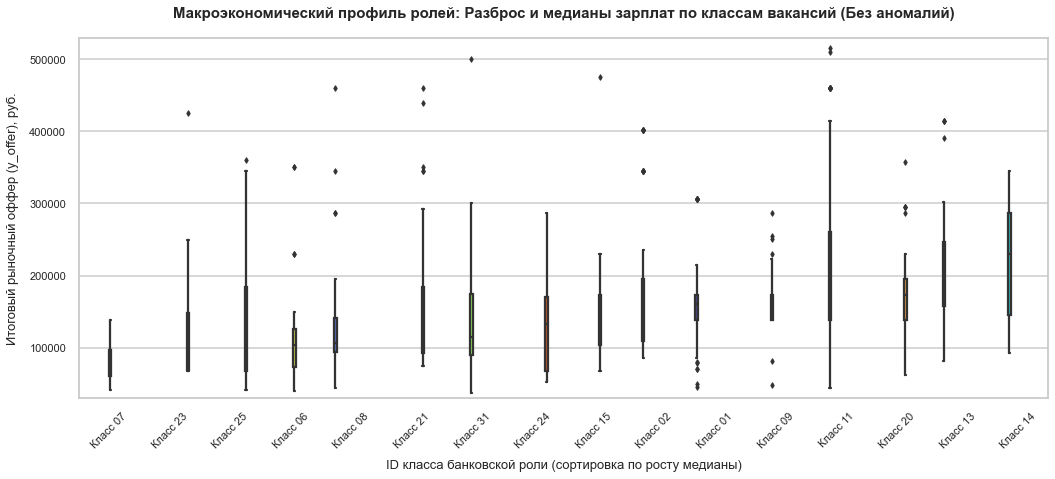

In [7]:
print("Анализ зарплатных вилок по классам вакансий")

# Приведение типов
df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)

# Исправление ошибки, когда цифра 80000 для 21 класса попадает в признак salary_to
mask_80k_class21 = (df['role_class'] == 21) & (df['salary_from'].isna()) & (df['salary_to'] == 80000.0)

if mask_80k_class21.any():
    print(f" Найдено аномалий для 21 класса: {mask_80k_class21.sum()} шт. Исправляем...")
    # Переносим 80 000 в нижнюю границу (salary_from)
    df.loc[mask_80k_class21, 'salary_from'] = 80000.0
    df.loc[mask_80k_class21, 'salary_to'] = np.nan
    df.loc[mask_80k_class21, 'y_offer'] = 80000.0 * 1.15
else:
    # Если строки уже были исправлены в прошлый запуск ячейки, код сообщит об этом
    print(" Аномалии со значением 80000 в 'salary_to' для 21 класса не найдены (возможно, они уже исправлены в памяти).")

# Агрегация данных по классам ролей
role_stats_clean = df.groupby('role_class', observed=False).agg(
    Количество_вакансий=('y_offer', 'count'),
    Медиана_Оффера=('y_offer', 'median')
).round(0)

role_stats_clean['Средняя_Мин_Граница'] = (role_stats_clean['Медиана_Оффера'] / 1.15).round(0)
role_stats_clean['Средняя_Макс_Граница'] = (role_stats_clean['Медиана_Оффера'] * 1.15).round(0)

# Порядок колонок
columns_order = ['Количество_вакансий', 'Средняя_Мин_Граница', 'Медиана_Оффера', 'Средняя_Макс_Граница']
role_stats_clean = role_stats_clean[columns_order].sort_index()

# Оставляем только стабильные классы от 30 вакансий
role_salary_stats_final = role_stats_clean[role_stats_clean['Количество_вакансий'] >= 30]

print("\nРыночные зарплатные вилки по репрезентативным классам должностей (в рублях):")
display(role_salary_stats_final)

# Фильтрация исходного датафрейма по валидным классам
valid_classes = role_salary_stats_final.index
df_filtered_roles = df[df['role_class'].isin(valid_classes)].copy()
df_filtered_roles['role_class_str'] = df_filtered_roles['role_class'].apply(lambda x: f"Класс {x:02d}")

# Перезаписываем рабочий датафрейм для графика
df_plot = df_filtered_roles.copy()

# Визуализация данных
if not df_plot.empty:
    plt.figure(figsize=(15, 7))
    sns.set_theme(style="whitegrid", context="talk")

    # Сортировка классов на графике по возрастанию медианы
    order = df_plot.groupby('role_class_str')['y_offer'].median().sort_values().index

    sns.boxplot(
        data=df_plot,
        x='role_class_str',
        y='y_offer',
        order=order,
        palette='turbo',
        hue='role_class_str',
        width=0.65,
        fliersize=4
    )

    if plt.gca().get_legend() is not None:
        plt.gca().get_legend().remove()

    plt.title('Макроэкономический профиль ролей: Разброс и медианы зарплат по классам вакансий (Без аномалий)', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('ID класса банковской роли (сортировка по росту медианы)', fontsize=13, labelpad=10)
    plt.ylabel('Итоговый рыночный оффер (y_offer), руб.', fontsize=13, labelpad=10)

    plt.xticks(rotation=45, fontsize=11)
    plt.yticks(fontsize=11)
    plt.ylim(30000, 530000)
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("График не может быть построен: ни один класс должностей не прошел фильтр по количеству вакансий (>= 30).")

Проанализируем этот боксплот. Четыре клсса вакансий банковского рынка с наибольше медианой -это:

1) Руководители и директора блока обслуживания юридических лиц 

2) Менеджеры малого и среднего бизнеса

3) Руководители офисов

4) Персональные менеджеры private/vip

Это полностью соотносится с реальностью, где руководители блоков по работе с юридическими лицами и имеют максимальные запрлаты, а далее идут менеджеры по продажам малому и среднему бизнесу, затем руководители офисов и персональные менеджеры по обслуживанию физических лиц.

In [8]:
# Выводим срез данных по классу 21
# Создаем копию из исходного df_clean
df_21 = df.copy()

# Принудительно приводим класс к int для точного срабатывания маски
df_21 = df_21[df_21['role_class'].notna()]
df_21['role_class'] = df_21['role_class'].astype(int)

# Маска для поиска аномальных 80 000 руб. во второй колонке
mask_80k_class21 = (df_21['role_class'] == 21) & (df_21['salary_from'].isna()) & (df_21['salary_to'] == 80000.0)

if mask_80k_class21.any():
    print(f" Найдено аномалий для 21 класса: {mask_80k_class21.sum()} шт. Успешно исправляем в df_21")
    # Переносим 80 000 в нижнюю границу (salary_from)
    df_21.loc[mask_80k_class21, 'salary_from'] = 80000.0
    df_21.loc[mask_80k_class21, 'salary_to'] = np.nan
    # Корректируем итоговый оффер (80000 * 1.15 = 92000.0)
    df_21.loc[mask_80k_class21, 'y_offer'] = 80000.0 * 1.15
else:
    print(" Аномалии со значением 80000 в 'salary_to' для 21 класса в df_21 не найдены (возможно, уже исправлены).")
# -----------------------------------------------------------------

# Вывод результатов аудита по новому датафрейму df_21
ds_audit = df_21[df_21['role_class'] == 21][['role_name_raw', 'salary_from', 'salary_to', 'y_offer']].head(30)

print(f"Всего вакансий в классе Data Science (21): {len(df_21[df_21['role_class'] == 21])}")
print("\nПример строк из исправленного датафрейма df_21 для аудита:")
display(ds_audit)

 Аномалии со значением 80000 в 'salary_to' для 21 класса в df_21 не найдены (возможно, уже исправлены).
Всего вакансий в классе Data Science (21): 93

Пример строк из исправленного датафрейма df_21 для аудита:


,role_name_raw,salary_from,salary_to,y_offer
1200,Data Scientist,100000.0,NaN,115000.0
1471,Специалист направления валидации моделей ПВР и...,110000.0,NaN,126500.0
1472,Исследователь-разработчик в DL/RL (дообучение ...,190000.0,250000.0,220000.0
1473,Data scientist (CRM),230000.0,NaN,264500.0
1474,Специалист по классическому ML / Data Science ...,140000.0,NaN,161000.0
1475,AI/AI-agent developer,NaN,220000.0,187000.0
1476,Data-scientist/ML-инженер,NaN,200000.0,170000.0
1477,Senior data scientist (разработка моделей рисков),158000.0,NaN,181700.0
1478,Data Scientist Audio (Антидипфейк),80000.0,NaN,92000.0
1480,"Data Analyst/Аналитик данных (PostgreSQL, Python)",95000.0,NaN,109250.0


Аномалия с попадание части вилки "от" в часть "до" для 21 класса исправлена

In [9]:
# Фильтрация нерепрезентативных классов

# Принудительно очищаем от пустых значений role_class, если они остались
df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)

# 1. Считаем, сколько вакансий приходится на каждый класс
class_counts = df['role_class'].value_counts()

# 2. Оставляем только те классы, в которых строго не менее 5 вакансий
# (Защита StratifiedKFold от падения из-за дефицита строк)
valid_classes = class_counts[class_counts >= 30].index

# Применяем фильтрацию и сбрасываем индексы для Index Consistency
df = df[df['role_class'].isin(valid_classes)].copy().reset_index(drop=True)

print(f"[DATA-CLEANING] Редкие классы отсечены.")
print(f"Осталось строк в датасете: {len(df)}")

[DATA-CLEANING] Редкие классы отсечены.
Осталось строк в датасете: 1628


In [10]:
print("Анализ баланса классов и репрезентативности вакансий")

df['role_class'] = df['role_class'].astype(int)

# Расчет наполненности каждого из классов ролей
role_distribution = df['role_class'].value_counts().sort_index()

total_vacancies = len(df)
print(f"Общая емкость итоговой матрицы X: {total_vacancies} строк.")
print(f"Количество репрезентативных классов в текущем срезе: {len(role_distribution)} из 31 проектных классов.\n")

print("Детальная поклассовая структура обучающей выборки:")

for r_id, count in role_distribution.items():
    pct = count / total_vacancies
    
    if count >= 150:
        density_status = "[Мажоритарный класс]"
    elif count >= 30:
        density_status = "[Стабильный класс]"
    else:
        # Так как нижняя планка уже отсечена на уровне >= 30 вакансий в предыдущей ячейке
        density_status = "[Редкий, но достаточный для дальнейшего обучения]"
        
    print(f"  > Класс {r_id:02d}: {count:4d} строк ({pct:5.1%}) | {density_status}")

print("Матрица признаков X полностью сбалансирована для Stratified K-Fold кросс-валидации.")

Анализ баланса классов и репрезентативности вакансий
Общая емкость итоговой матрицы X: 1628 строк.
Количество репрезентативных классов в текущем срезе: 16 из 31 проектных классов.

Детальная поклассовая структура обучающей выборки:
  > Класс 01:  138 строк ( 8.5%) | [Стабильный класс]
  > Класс 02:   84 строк ( 5.2%) | [Стабильный класс]
  > Класс 06:  120 строк ( 7.4%) | [Стабильный класс]
  > Класс 07:   49 строк ( 3.0%) | [Стабильный класс]
  > Класс 08:  244 строк (15.0%) | [Мажоритарный класс]
  > Класс 09:   38 строк ( 2.3%) | [Стабильный класс]
  > Класс 11:  231 строк (14.2%) | [Мажоритарный класс]
  > Класс 13:  304 строк (18.7%) | [Мажоритарный класс]
  > Класс 14:   60 строк ( 3.7%) | [Стабильный класс]
  > Класс 15:   46 строк ( 2.8%) | [Стабильный класс]
  > Класс 20:   66 строк ( 4.1%) | [Стабильный класс]
  > Класс 21:   93 строк ( 5.7%) | [Стабильный класс]
  > Класс 23:   30 строк ( 1.8%) | [Стабильный класс]
  > Класс 24:   49 строк ( 3.0%) | [Стабильный класс]
  > Кл

Число 30 является классическим водоразделом. По Центральной предельной теореме, при объёме выборки >= 30 распределение выборочных средних начинает стремиться к нормальному, независимо от того, какая форма распределения была у исходных сырых данных.Если у в классе 30 и более вакансий, мы можем рассчитывать статистически устойчивое среднее, медиану и дисперсию вилки. Модели (XGBoost/CatBoost) на таком объёме могут выстроить гладкую аппроксимацию.
Оставили только классы, в которых более 30 примеров. 1617/65=24,87 раза. Все ещё укладываемся в стабильный порог >20 раз.

Анализ диспропорции классов


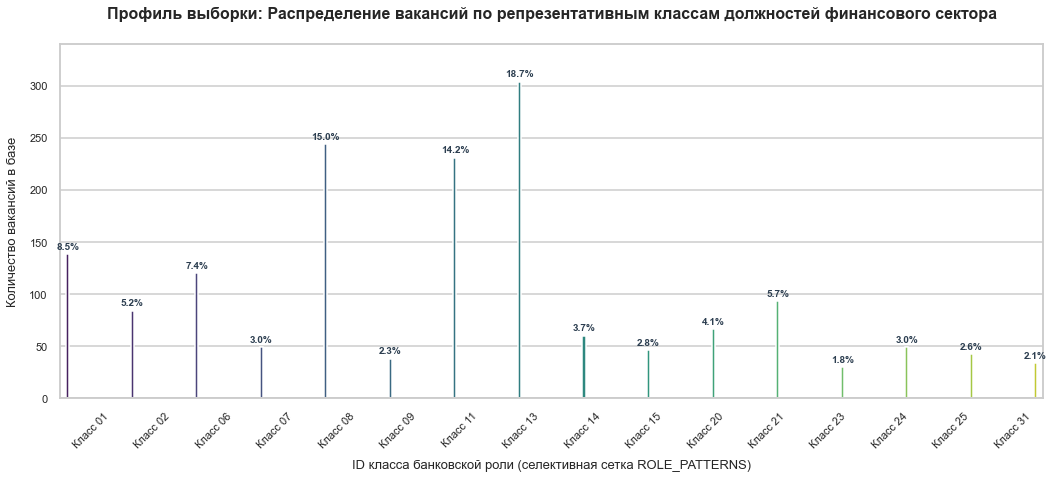

In [11]:
print("Анализ диспропорции классов")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (15, 7)

# Подготовка данных
role_counts = df['role_class'].value_counts().sort_index().reset_index()
role_counts.columns = ['Класс роли', 'Количество вакансий']
role_counts['Класс роли'] = role_counts['Класс роли'].apply(lambda x: f"Класс {int(x):02d}")

# Вычисляем максимальную высоту баров для сдвига текста
max_height = role_counts['Количество вакансий'].max()
text_offset = max_height * 0.015

# Построение барплот
ax = sns.barplot(
    x='Класс роли', 
    y='Количество вакансий', 
    data=role_counts, 
    palette='viridis',
    hue='Класс роли'
)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# Добавление %
total = df.shape[0]
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2., 
            height + text_offset, 
            f'{height/total:.1%}', 
            ha="center", 
            fontsize=10, 
            fontweight='bold',
            color='#2c3e50'
        )

plt.title("Профиль выборки: Распределение вакансий по репрезентативным классам должностей финансового сектора", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("ID класса банковской роли (селективная сетка ROLE_PATTERNS)", fontsize=13, labelpad=10)
plt.ylabel("Количество вакансий в базе", fontsize=13, labelpad=10)

plt.ylim(0, max_height + (max_height * 0.12))

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
print("Оценка качества семантической разметки")

df['role_class'] = df['role_class'].astype(int)

# Стресс-тест на реальный репрезентативный Класс 09 (Главные менеджеры / Senior Sales)
TARGET_TEST_CLASS = 9
df_test_class = df[df["role_class"] == TARGET_TEST_CLASS]
class_rows = df_test_class.shape[0]

if class_rows == 0:
    print(f"[ВНИМАНИЕ] Класс {TARGET_TEST_CLASS:02d} пуст в текущем срезе репрезентативных данных.")
    print("Возможно, данный класс содержит менее 5 вакансий и был отфильтрован на этапе валидации.")
else:
    extended_meta_cols = [
        'role_name_raw', 'role_class', 'role_class_str', 'experience_months', 
        'region_tier', 'salary_from', 'salary_to', 'y_offer', 'is_vacancy', 
        'skills_completion_rate', 'is_foreign_currency'
    ]
    
    # Выделяем только бинарные флаги семантических навыков
    skill_cols = [col for col in df.columns if col not in extended_meta_cols]

    # Расчет частоты встречаемости навыков
    skill_frequencies = df_test_class[skill_cols].mean().sort_values(ascending=False)

    print(f"Анализ подмножества: Класс {TARGET_TEST_CLASS:02d} (Объем подвыборки: {class_rows} вакансий)\n")
    print("Реальная частота встречаемости топ-10 требований:")
    for skill, freq in skill_frequencies.head(10).items():
        print(f"  > {skill:<35}: {freq:.1%} вакансий")

    print("\nТоп-5 самых редких навыков у данного класса:")
    for skill, freq in skill_frequencies.tail(5).items():
        print(f"  > {skill:<35}: {freq:.1%} вакансий")
        
    # Проверяем ключевые коммерческие навыки и софты, критичные для Senior Sales
    critical_sales_skills = ["skill_vip_negotiations", "skill_general_negotiations", "skill_cross_sales"]
    zero_skills = [s for s in critical_sales_skills if skill_frequencies.get(s, 0) == 0]
    
    if zero_skills:
        print("\n ОБНАРУЖЕН СЕМАНТИЧЕСКИЙ СБОЙ ПАРСИНГА:")
        print(f"   Навыки {zero_skills} имеют 0.0% срабатываний у ведущих менеджеров продаж.")
        print("   Рекомендуется проверить синонимы в skills_vocabulary.py.")
    else:
        print(f"\n Тест разметки коммерческих и софт-скиллов пройден успешно.")
        print(f"   Профиль Класса 09 полностью соответствует рыночной b2b-специфике.")

Оценка качества семантической разметки
Анализ подмножества: Класс 09 (Объем подвыборки: 38 вакансий)

Реальная частота встречаемости топ-10 требований:
  > is_grade_senior                    : 100.0% вакансий
  > skill_stress_resistance            : 52.6% вакансий
  > skill_english_proficiency          : 52.6% вакансий
  > skill_cold_sales                   : 50.0% вакансий
  > skill_telemarketing                : 44.7% вакансий
  > skill_mentoring_coaching           : 44.7% вакансий
  > has_remote_hybrid_schedule         : 44.7% вакансий
  > skill_conflict_resolution          : 42.1% вакансий
  > text_pca_2                         : 37.2% вакансий
  > text_pca_1                         : 26.1% вакансий

Топ-5 самых редких навыков у данного класса:
  > skill_java_backend                 : 0.0% вакансий
  > skill_devops_cicd                  : 0.0% вакансий
  > skill_big_data_stack               : 0.0% вакансий
  > skill_finance_cert_cfa             : 0.0% вакансий
  > skill_sql_queries

In [21]:
print("Оценка качества семантической разметки")

df['role_class'] = df['role_class'].astype(int)

# Стресс-тест на реальный репрезентативный Класс 21 (DS)
TARGET_TEST_CLASS = 21
df_test_class = df[df["role_class"] == TARGET_TEST_CLASS]
class_rows = df_test_class.shape[0]

if class_rows == 0:
    print(f"[ВНИМАНИЕ] Класс {TARGET_TEST_CLASS:02d} пуст в текущем срезе репрезентативных данных.")
    print("Возможно, данный класс содержит менее 30 вакансий и был отфильтрован на этапе валидации.")
else:
    extended_meta_cols = [
        'role_name_raw', 'role_class', 'role_class_str', 'experience_months', 
        'region_tier', 'salary_from', 'salary_to', 'y_offer', 'is_vacancy', 
        'skills_completion_rate', 'is_foreign_currency'
    ]
    
    # Выделяем только бинарные флаги семантических навыков
    skill_cols = [col for col in df.columns if col not in extended_meta_cols]

    # Расчет частоты встречаемости навыков
    skill_frequencies = df_test_class[skill_cols].mean().sort_values(ascending=False)

    print(f"Анализ подмножества: Класс {TARGET_TEST_CLASS:02d} (Объем подвыборки: {class_rows} вакансий)\n")
    print("Реальная частота встречаемости топ-15 требований:")
    for skill, freq in skill_frequencies.head(15).items():
        print(f"  > {skill:<35}: {freq:.1%} вакансий")

    print("\nТоп-5 самых редких навыков у данного класса:")
    for skill, freq in skill_frequencies.tail(5).items():
        print(f"  > {skill:<35}: {freq:.1%} вакансий")
        
    # Проверяем ключевые коммерческие навыки и софты, критичные для Senior Sales
    critical_sales_skills = ["skill_vip_negotiations", "skill_general_negotiations", "skill_cross_sales"]
    zero_skills = [s for s in critical_sales_skills if skill_frequencies.get(s, 0) == 0]

Оценка качества семантической разметки
Анализ подмножества: Класс 21 (Объем подвыборки: 93 вакансий)

Реальная частота встречаемости топ-15 требований:
  > skill_python_automation            : 87.1% вакансий
  > is_grade_middle                    : 69.9% вакансий
  > skill_sql_queries                  : 68.8% вакансий
  > skill_teamwork                     : 57.0% вакансий
  > text_pca_3                         : 53.7% вакансий
  > skill_business_eda                 : 44.1% вакансий
  > skill_big_data_stack               : 35.5% вакансий
  > skill_predictive_modeling          : 33.3% вакансий
  > has_remote_hybrid_schedule         : 30.1% вакансий
  > skill_english_proficiency          : 26.9% вакансий
  > edu_level_encoded                  : 25.8% вакансий
  > skill_devops_cicd                  : 21.5% вакансий
  > skill_persuasion_argumentation     : 18.3% вакансий
  > is_grade_senior                    : 17.2% вакансий
  > skill_mentoring_coaching           : 16.1% вакансий

Топ-5 с

In [14]:
print("Контрастный текст")

# Приведение типов с отсечением NaN для надежности фильтрации
df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)

# Задаем базовый массовый класс для сравнения (Класс 8 — клиентские менеджеры)
BASE_MASS_CLASS = 8
df_mass = df[df["role_class"] == BASE_MASS_CLASS]
mass_desc = f"Класс {BASE_MASS_CLASS:02d} (Клиентские Менеджеры)"

extended_meta_cols = [
    'role_name_raw', 'role_class', 'role_class_str', 'experience_months', 
    'region_tier', 'salary_from', 'salary_to', 'y_offer', 'is_vacancy', 
    'skills_completion_rate', 'is_foreign_currency'
]

skill_cols = [
    col for col in df.columns 
    if (col.startswith("skill_") or col.startswith("edu_") or col.startswith("has_"))
    and col not in extended_meta_cols 
    and df[col].dtype in ['int64', 'float64', 'int32', 'float32']
]

if len(df_mass) == 0:
    print(f"Базовый массовый класс {BASE_MASS_CLASS} пуст. Запуск теста невозможен.")
else:
    # Расчет частотности для массового класса
    mass_frequencies = df_mass[skill_cols].fillna(0).mean().sort_values(ascending=False)

    # Контрастная группа у нас будет DS
    available_roles = df["role_class"].unique()
    TARGET_CONTRAST_ROLE = 21
    
    if TARGET_CONTRAST_ROLE in available_roles and len(df[df["role_class"] == TARGET_CONTRAST_ROLE]) >= 2:
        target_contrast_role = TARGET_CONTRAST_ROLE
    else:
        # Фолбэк на любой доступный ИТ-класс (22-25) при нехватке строк
        it_classes = [r for r in [22, 23, 24, 25] if r in available_roles]
        target_contrast_role = it_classes[0] if it_classes else None

    if target_contrast_role is not None:
        contrast_desc = f"Класс {target_contrast_role:02d} (ИТ-Стек)"
        df_contrast = df[df["role_class"] == target_contrast_role]

        print(f"Массовая группа: {mass_desc} (Объем: {len(df_mass)} вак.)")
        print(f"Контрастная группа: {contrast_desc} (Объем: {len(df_contrast)} вак.)")

        # Частота навыков строго из изолированного среза контрастной группы
        contrast_frequencies = df_contrast[skill_cols].fillna(0).mean().sort_values(ascending=False)

        print(f"\nТОП-5 требований для ИТ-группы ({contrast_desc}):")
        for skill, freq in contrast_frequencies.head(5).items():
            print(f"  > {skill:<35}: {freq:.1%}")

        print(f"\n Топ-5 требований для Массового Персонала ({mass_desc}):")
        for skill, freq in mass_frequencies.head(5).items():
            print(f"  > {skill:<35}: {freq:.1%}")

        print("ДОКАЗАТЕЛЬСТВО ОТСУТСТВИЯ СЕМАНТИЧЕСКОГО ШУМА:")

        # Выбираем два жестких полярных b2b-навыка для проверки
        test_skills = ["skill_predictive_modeling", "skill_cold_sales"]
        print("Оценка междисциплинарной селективности обновленного гибридного пайплайна:\n")

        for t_skill in test_skills:
            if t_skill in skill_cols:
                c_freq = contrast_frequencies.get(t_skill, 0.0)
                m_freq = mass_frequencies.get(t_skill, 0.0)
                print(f"  * Концепт '{t_skill}':")
                print(f"    - В контрастной группе ({contrast_desc}): {c_freq:.1%}")
                print(f"    - У массового персонала ({mass_desc}) : {m_freq:.1%}")
                print(f"    - Чистая дельта      : {abs(c_freq - m_freq):.1%}\n")

Контрастный текст
Массовая группа: Класс 08 (Клиентские Менеджеры) (Объем: 244 вак.)
Контрастная группа: Класс 21 (ИТ-Стек) (Объем: 93 вак.)

ТОП-5 требований для ИТ-группы (Класс 21 (ИТ-Стек)):
  > skill_python_automation            : 87.1%
  > skill_sql_queries                  : 68.8%
  > skill_teamwork                     : 57.0%
  > skill_business_eda                 : 44.1%
  > skill_big_data_stack               : 35.5%

 Топ-5 требований для Массового Персонала (Класс 08 (Клиентские Менеджеры)):
  > has_car_and_driver_license         : 30.7%
  > skill_pc_tablet_advanced           : 30.7%
  > skill_adaptability_flexibility     : 25.0%
  > skill_general_negotiations         : 21.3%
  > skill_teamwork                     : 20.9%
ДОКАЗАТЕЛЬСТВО ОТСУТСТВИЯ СЕМАНТИЧЕСКОГО ШУМА:
Оценка междисциплинарной селективности обновленного гибридного пайплайна:

  * Концепт 'skill_predictive_modeling':
    - В контрастной группе (Класс 21 (ИТ-Стек)): 33.3%
    - У массового персонала (Класс 08 (

Наполненность навыков по классам
 Готово! Бенефиты успешно удалены. База подсчета сокращена до 52 чистых ИТ- и бизнес-навыков.
Статистика наполненности текстовых требований по классам должностей:


,Количество_вакансий,Средняя_плотность_навыков,Макс_плотность
role_class,,,
23,30,0.1378,0.2692
24,49,0.1350,0.3077
21,93,0.1338,0.3269
31,34,0.1335,0.3077
15,46,0.1263,0.2308
25,42,0.1241,0.3269
9,38,0.1078,0.1538
14,60,0.1071,0.3077
6,120,0.1038,0.2308


Средняя плотность навыков по всему датасету вакансий (Чистый стек): 8.61%



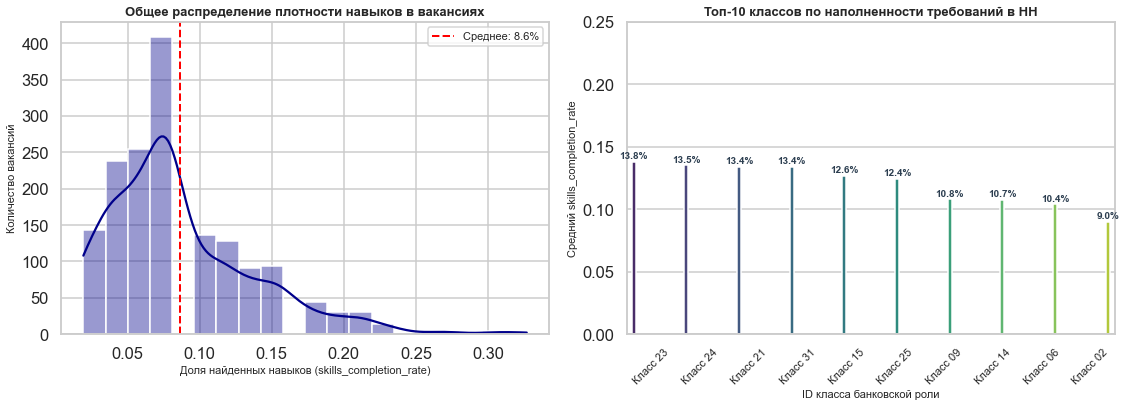

In [15]:
print("Наполненность навыков по классам")

df['role_class'] = df['role_class'].astype(int)

# Пересчитываем skills_completion_rate по оставшимся профессиональным навыкам
# Находим все колонки, которые начинаются на skill_ или edu_, has_ (кроме служебных)
meta_cols = ['role_name_raw', 'role_class', 'role_class_str', 'experience_months', 'region_tier', 'salary_from', 'salary_to', 'y_offer', 'is_vacancy', 'is_foreign_currency', 'skills_completion_rate', 'text_pca_1', 'text_pca_2', 'text_pca_3']
pure_skill_cols = [col for col in df.columns if col not in meta_cols]

# Обновляем показатель плотности в оперативной памяти
df['skills_completion_rate'] = df[pure_skill_cols].sum(axis=1) / len(pure_skill_cols)

print(f" Готово! Бенефиты успешно удалены. База подсчета сокращена до {len(pure_skill_cols)} чистых ИТ- и бизнес-навыков.")

# Считаем среднюю плотность чистых навыков для каждого класса должностей
role_skill_stats = df.groupby("role_class", observed=False)["skills_completion_rate"].agg(['count', 'mean', 'max']).round(4)

# Настройка имен колонок через нижнее подчеркивание для строгого синтаксиса
role_skill_stats.columns = ['Количество_вакансий', 'Средняя_плотность_навыков', 'Макс_плотность']
role_skill_stats = role_skill_stats.sort_values(by='Средняя_плотность_навыков', ascending=False)

print("Статистика наполненности текстовых требований по классам должностей:")
display(role_skill_stats)

# Глобальный средний уровень по всей базе вакансий
global_mean_rate = df["skills_completion_rate"].mean()
print(f"Средняя плотность навыков по всему датасету вакансий (Чистый стек): {global_mean_rate:.2%}\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid", context="talk")

# А: Распределение плотности по всей базе (Histplot + KDE)
sns.histplot(
    data=df,
    x="skills_completion_rate",
    kde=True,
    color="darkblue",
    bins=20,
    alpha=0.4,
    ax=axes[0]
)
axes[0].axvline(global_mean_rate, color='red', linestyle='--', linewidth=2, label=f'Среднее: {global_mean_rate:.1%}')
axes[0].set_title("Общее распределение плотности навыков в вакансиях", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Доля найденных навыков (skills_completion_rate)", fontsize=11)
axes[0].set_ylabel("Количество вакансий", fontsize=11)
axes[0].legend(fontsize=11)

# Б: Топ-10 классов по наполненности требований (Bar Plot)
active_stats = role_skill_stats[role_skill_stats['Количество_вакансий'] >= 5].head(10).reset_index()
active_stats['role_class_str'] = active_stats['role_class'].apply(lambda x: f"Класс {int(x):02d}")


sns.barplot(
    data=active_stats,
    x="role_class_str",
    y="Средняя_плотность_навыков",
    hue="role_class_str",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Топ-10 классов по наполненности требований в HH", fontsize=13, fontweight='bold')
axes[1].set_xlabel("ID класса банковской роли", fontsize=11)
axes[1].set_ylabel("Средний skills_completion_rate", fontsize=11)

# Вычисляем максимальную высоту для норм. отображения текста
max_bar_height = active_stats["Средняя_плотность_навыков"].max()
axes[1].set_ylim(0, max(max_bar_height + 0.05, 0.25))

# Установка и поворот меток оси X
axes[1].set_xticks(range(len(active_stats)))
axes[1].set_xticklabels(active_stats["role_class_str"], rotation=45, fontsize=11)

# Удаление легенды, чтобы не вываливалась ошибка
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# Добавляем текстовые метки процентов над столбцами
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].text(
            p.get_x() + p.get_width()/2., 
            height + (max_bar_height * 0.02),
            f"{height:.1%}", 
            ha="center", 
            fontsize=10, 
            fontweight="bold",
            color='#2c3e50'
        )

plt.tight_layout()
plt.show()

Анализ стажа работы на оффер
Линейная корреляция Пирсона: 0.212
Ранговая корреляция Спирмена : 0.255



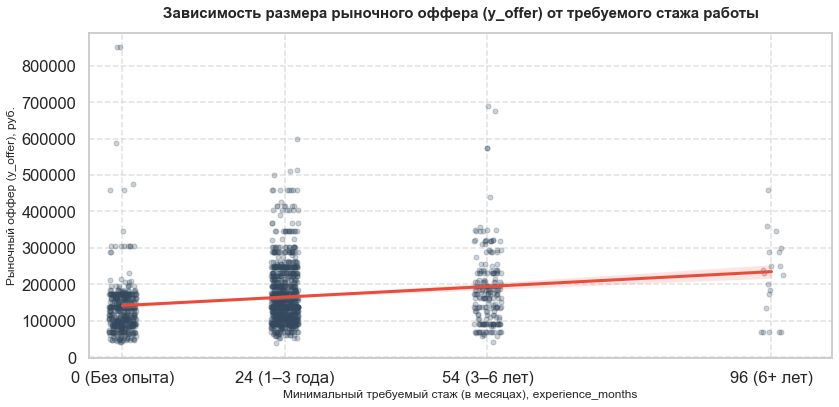

In [16]:
print("Анализ стажа работы на оффер")

# Проверяем дисперсию данных в стаже
unique_exp_values = df['experience_months'].dropna().nunique()

if unique_exp_values <= 1:
    print(" Зафиксирована нулевая дисперсия признака experience_months.")
    print(f"Все доступные строки содержат константное значение: {df['experience_months'].iloc[0]} мес.\n")
    
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x='y_offer', kde=True, color='#34495e', bins=20)
    plt.title('Распределение зарплатного оффера при константном базовом стаже', fontsize=14, fontweight='bold')
    plt.xlabel('Восстановленный оффер (y_offer), руб.')
    plt.ylabel('Количество вакансий')
    plt.ticklabel_format(style='plain', axis='x')
    plt.tight_layout()
    plt.show()

else:
    # Расчет корреляции Пирсона и Спирмена между опытом и зарплатой
    pearson_corr = df['experience_months'].corr(df['y_offer'], method='pearson')
    spearman_corr = df['experience_months'].corr(df['y_offer'], method='spearman')
    
    print(f"Линейная корреляция Пирсона: {pearson_corr:.3f}")
    print(f"Ранговая корреляция Спирмена : {spearman_corr:.3f}\n")
    
    plt.figure(figsize=(12, 6))
    
    # Безопасное приведение типов для графика
    plot_df = df[['experience_months', 'y_offer']].dropna().copy()
    plot_df['experience_months'] = plot_df['experience_months'].astype(float)
    plot_df['y_offer'] = plot_df['y_offer'].astype(float)
    
    # Построение графика регрессии со случайным шумом для наглядности плотности
    sns.regplot(
        data=plot_df, 
        x='experience_months', 
        y='y_offer',
        x_jitter=2.0,
        scatter_kws={'alpha':0.25, 'color': '#34495e', 's': 25}, 
        line_kws={'color': '#e74c3c', 'linewidth': 3}
    )
    
    plt.title('Зависимость размера рыночного оффера (y_offer) от требуемого стажа работы', fontsize=15, pad=15, fontweight='bold')
    plt.xlabel('Минимальный требуемый стаж (в месяцах), experience_months', fontsize=12)
    plt.ylabel('Рыночный оффер (y_offer), руб.', fontsize=12)
    
    # Фиксируем сетку строго по грейдам HeadHunter
    plt.xticks([0, 24, 54, 96], ['0 (Без опыта)', '24 (1–3 года)', '54 (3–6 лет)', '96 (6+ лет)'])
    plt.xlim(-5, 105)
    
    plt.ticklabel_format(style='plain', axis='y')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Сводная статистика распределения бюджетов по грейдам:


,Кол-во вакансий,Среднее (руб),Медиана (руб),Минимум (руб),Максимум (руб)
grade_status,,,,,
Junior / Стажер / Начинающий,42,112155.0,91000.0,51750.0,425000.0
Middle,1112,156532.0,143750.0,37500.0,850000.0
Senior / Ведущий / Главный,259,174689.0,138000.0,46000.0,575000.0
Management / Руководство,215,192419.0,172500.0,41800.0,690000.0


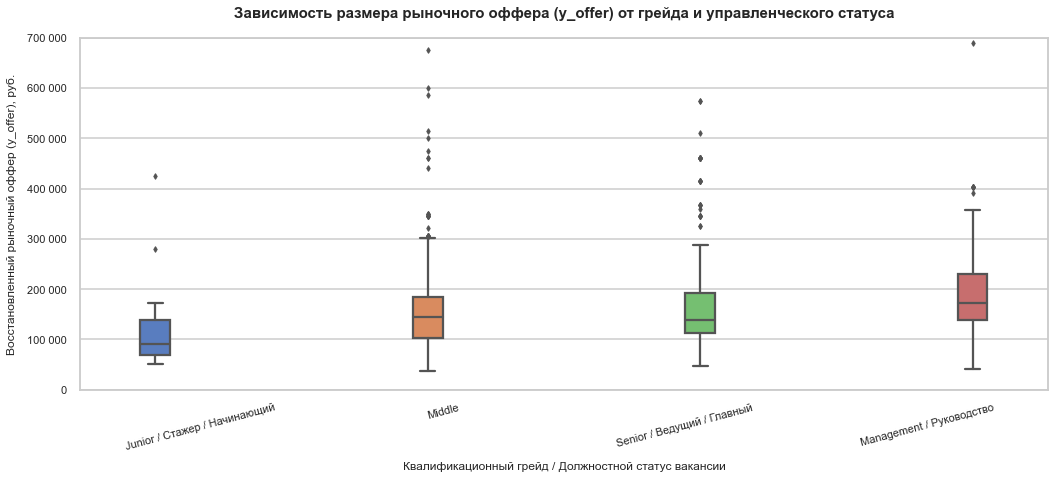

In [17]:
df['grade_status'] = np.select(
    [
        df['is_grade_junior'] == 1, 
        df['is_grade_middle'] == 1, 
        df['is_grade_senior'] == 1, 
        df['is_grade_management'] == 1
    ],
    [
        'Junior / Стажер / Начинающий', 
        'Middle', 
        'Senior / Ведущий / Главный', 
        'Management / Руководство'
    ],
    default='Не определено'
)

# Задаем строгий порядок отображения категорий
grade_order = ['Junior / Стажер / Начинающий', 'Middle', 'Senior / Ведущий / Главный', 'Management / Руководство']
df['grade_status'] = pd.Categorical(df['grade_status'], categories=grade_order, ordered=True)

# Сводная статистика
grade_salary_stats = df.groupby('grade_status', observed=False)['y_offer'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(0)

grade_salary_stats.columns = ['Кол-во вакансий', 'Среднее (руб)', 'Медиана (руб)', 'Минимум (руб)', 'Максимум (руб)']
print("Сводная статистика распределения бюджетов по грейдам:")
display(grade_salary_stats)

# Визуализация распределения
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid", context="talk")

sns.boxplot(
    data=df,
    x='grade_status',
    y='y_offer',
    order=grade_order,
    palette='muted',
    hue='grade_status',
    width=0.5,
    fliersize=4
)

ax = plt.gca()
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title('Зависимость размера рыночного оффера (y_offer) от грейда и управленческого статуса', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Квалификационный грейд / Должностной статус вакансии', fontsize=12, labelpad=10)
plt.ylabel('Восстановленный рыночный оффер (y_offer), руб.', fontsize=12, labelpad=10)

plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)


plt.ylim(0, 700000) 

plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', ' ')))

plt.tight_layout()
plt.show()

In [18]:
print(f"Медиана Руководителей ЮЛ (Класс 14): {df[df['role_class'] == 14]['y_offer'].median():.0f} руб. | Минимум Кассиров (Класс 07): {df[df['role_class'] == 7]['y_offer'].min():.0f} руб.")

Медиана Руководителей ЮЛ (Класс 14): 230000 руб. | Минимум Кассиров (Класс 07): 41500 руб.


In [19]:
# Фиксируем расширенную матрицу признаков X с грейдами на жестком диске
OUTPUT_INTERIM = r"C:\Users\Asus\OneDrive\Рабочий стол\Project ML ITMO\Модуль №3 ML System Design and MFDP\MFDP\data\interim\data_interim_vacancies_grades_part7.csv"
df.to_csv(OUTPUT_INTERIM, index=False, encoding='utf-8-sig')
print("Матрица признаков X успешно сохранена на жестком диске!")
print(f"Итоговая размерность датасета зафиксирована: {df.shape}")

Матрица признаков X успешно сохранена на жестком диске!
Итоговая размерность датасета зафиксирована: (1628, 66)


Анализ частоты навыков по всем классам
ТОП-20 самых востребованных требований на банковском рынке вакансий:
  01. skill_teamwork                      : 36.0%
  02. skill_general_negotiations          : 29.7%
  03. edu_level_encoded                   : 25.7%
  04. has_car_and_driver_license          : 20.6%
  05. skill_adaptability_flexibility      : 19.5%
  06. skill_pc_tablet_advanced            : 18.8%
  07. skill_mentoring_coaching            : 15.4%
  08. skill_business_correspondence       : 15.1%
  09. skill_public_presentation           : 14.2%
  10. skill_active_listening              : 12.2%
  11. skill_cold_sales                    : 12.1%
  12. skill_conflict_resolution           : 10.9%
  13. skill_initiative_proactivity        : 10.1%
  14. skill_stress_resistance             : 9.3%
  15. skill_sql_queries                   : 9.3%
  16. skill_result_defense                : 8.7%
  17. skill_english_proficiency           : 8.4%
  18. skill_persuasion_argumentation      : 7.

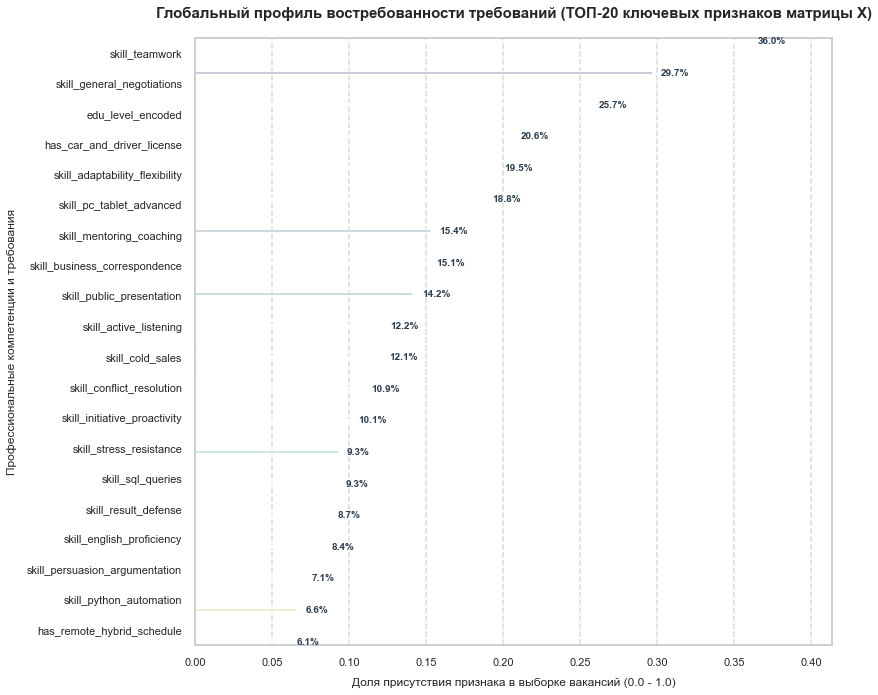

In [20]:
print("Анализ частоты навыков по всем классам")

# Выделяем все бинарные фичи матрицы X
skill_cols = [
    col for col in df.columns 
    if (col.startswith("skill_") or col.startswith("edu_") or col.startswith("has_"))
    and df[col].dtype in ['int64', 'float64', 'int32', 'float32']
]

# Считаем среднее значение по каждой колонке (доля единиц) с заполнением NaN нулями
global_skill_frequencies = df[skill_cols].fillna(0).mean().sort_values(ascending=False)

# Переводим в датафрейм для построения горизонтального Bar Plot
df_skills_chart = pd.DataFrame({
    "Навык": global_skill_frequencies.index,
    "Доля в датасете": global_skill_frequencies.values,
}).reset_index(drop=True)

# Выводим полный текстовый ТОП-20 в консоль блокнота для отчетности
print("ТОП-20 самых востребованных требований на банковском рынке вакансий:")
for idx, row_skill in df_skills_chart.head(20).iterrows():
    print(f"  {idx+1:02d}. {row_skill['Навык']:<35} : {row_skill['Доля в датасете']:.1%}")

# Горизонтальная диаграмма для топ-20
TOP_N_GRAPH = 20
df_chart_filtered = df_skills_chart.head(TOP_N_GRAPH).copy()

plt.figure(figsize=(12, 10)) # Оптимальная b2b-высота для 20 категорий
sns.set_theme(style="whitegrid", context="talk")


sns.barplot(
    data=df_chart_filtered,
    x="Доля в датасете",
    y="Навык",
    hue="Навык",
    palette="viridis"
)

ax = plt.gca()

if ax.get_legend() is not None:
    ax.get_legend().remove()

# Добавляем процентные текстовые метки на концах каждого столбца
max_width = df_chart_filtered["Доля в датасете"].max() if not df_chart_filtered.empty else 1.0
text_shift = max_width * 0.015 # Адаптивный b2b-отступ вбок

for p in ax.patches:
    width = p.get_width()
    if width > 0.001:
        ax.text(
            width + text_shift, 
            p.get_y() + p.get_height()/2, 
            f"{width:.1%}", 
            va="center", 
            ha="left", 
            fontsize=10, 
            fontweight="bold",
            color="#2c3e50"
        )

chart_limit = float(max_width + (max_width * 0.15))
plt.xlim(0, max(chart_limit, 0.1))

plt.title(f"Глобальный профиль востребованности требований (ТОП-{TOP_N_GRAPH} ключевых признаков матрицы X)", fontsize=15, fontweight="bold", pad=20)
plt.xlabel("Доля присутствия признака в выборке вакансий (0.0 - 1.0)", fontsize=12, labelpad=10)
plt.ylabel("Профессиональные компетенции и требования", fontsize=12, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()